# TP 2 : Analyse des Frontières de Décision avec Régression Logistique (Régularisations L1 & L2)

**L'objectif** de ce TP est d'étudier l'impact des transformations polynomiales sur la flexibilité des frontières de décision, et d'analyser comment l'application de pénalités (L1 et L2) permet de contrôler le surapprentissage (overfitting) induit par des caractéristiques de haut degré.

## 1. Préparation des Données

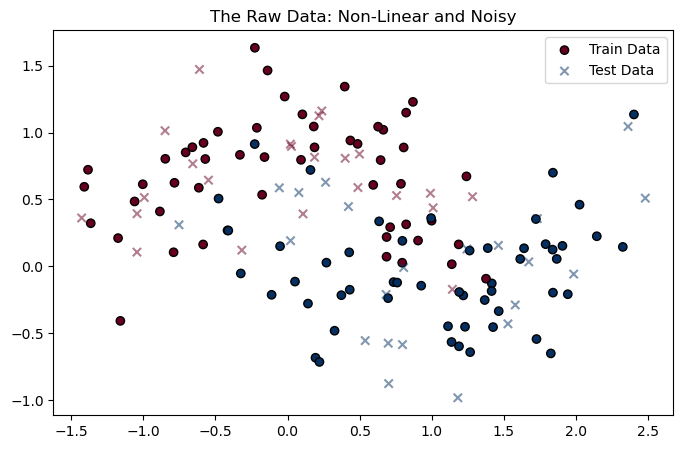

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Generate noisy data
X, y = make_moons(n_samples=150, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Plot the raw data
plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdBu', edgecolors='k', label='Train Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu', marker='x', alpha=0.5, label='Test Data')
plt.title("The Raw Data: Non-Linear and Noisy")
plt.legend()
plt.show()

## 2. Transformation Polynomiale et Standardisation (Mise en échelle)

In [46]:
import warnings

# Hide sklearn deprecation warnings related to logistic penalty API changes
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.linear_model._logistic")

# Modèles
models = [
    ("No Regular", LogisticRegression(penalty=None)),
    ("L1 Lasso", LogisticRegression(penalty='l1', solver='liblinear', C=0.5)),
    ("L2 Ridge", LogisticRegression(penalty='l2', C=0.5))
]

# Polynomiale et Normalisation des données
poly = PolynomialFeatures(degree=10, include_bias=False)
scaler = StandardScaler()

X_train_poly = scaler.fit_transform(poly.fit_transform(X_train))
X_test_poly = scaler.transform(poly.transform(X_test))


## 3. Entraînement des Modèles : Régression Logistique (Pénalités L1 vs L2)

In [47]:
# Entraînement et évaluation
for name, model in models:
    model.fit(X_train_poly, y_train)
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"{name} : Accuracy de Train: {train_accuracy:.2f}")
    print(f"{name} : Accuracy de Test: {test_accuracy:.2f}")

No Regular : Accuracy de Train: 0.91
No Regular : Accuracy de Test: 0.84
L1 Lasso : Accuracy de Train: 0.86
L1 Lasso : Accuracy de Test: 0.84
L2 Ridge : Accuracy de Train: 0.88
L2 Ridge : Accuracy de Test: 0.84


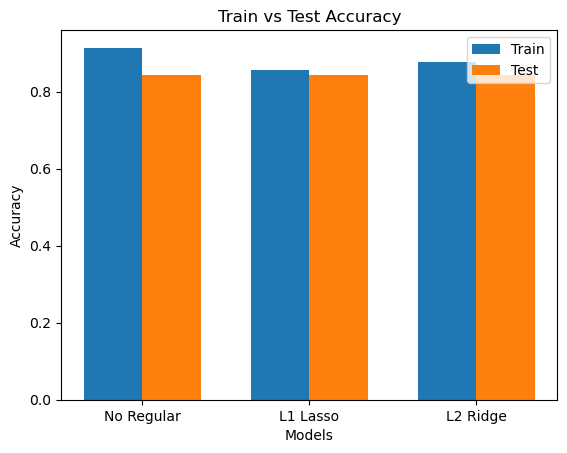

In [48]:
import numpy as np

names = [name for name, _ in models]
train_scores = []
test_scores = []

for _, clf in models:
    clf.fit(X_train_poly, y_train)
    train_scores.append(clf.score(X_train_poly, y_train))
    test_scores.append(clf.score(X_test_poly, y_test))

x = np.arange(len(names))
width = 0.35

plt.figure()
plt.bar(x - width/2, train_scores, width)
plt.bar(x + width/2, test_scores, width)

plt.xticks(x, names)
plt.title("Train vs Test Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.legend(["Train", "Test"])
plt.show()

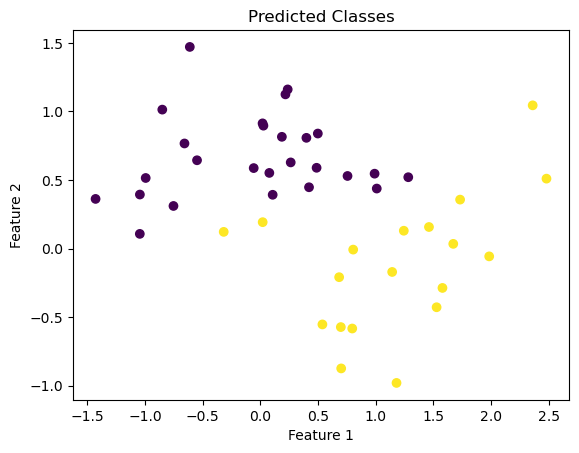

In [49]:
import matplotlib.pyplot as plt

# Train model
model = LogisticRegression(max_iter=5000)
model.fit(X_train_poly, y_train)

# Predict
y_pred = model.predict(X_test_poly)

plt.figure()
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Predicted Classes")
plt.show()

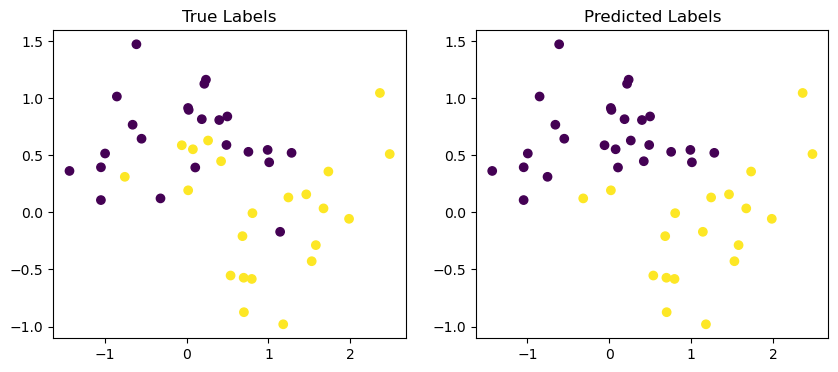

In [50]:
plt.figure(figsize=(10,4))

# True labels
plt.subplot(1,2,1)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test)
plt.title("True Labels")

# Predicted labels
plt.subplot(1,2,2)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)
plt.title("Predicted Labels")

plt.show()

## Visualisation des Frontières

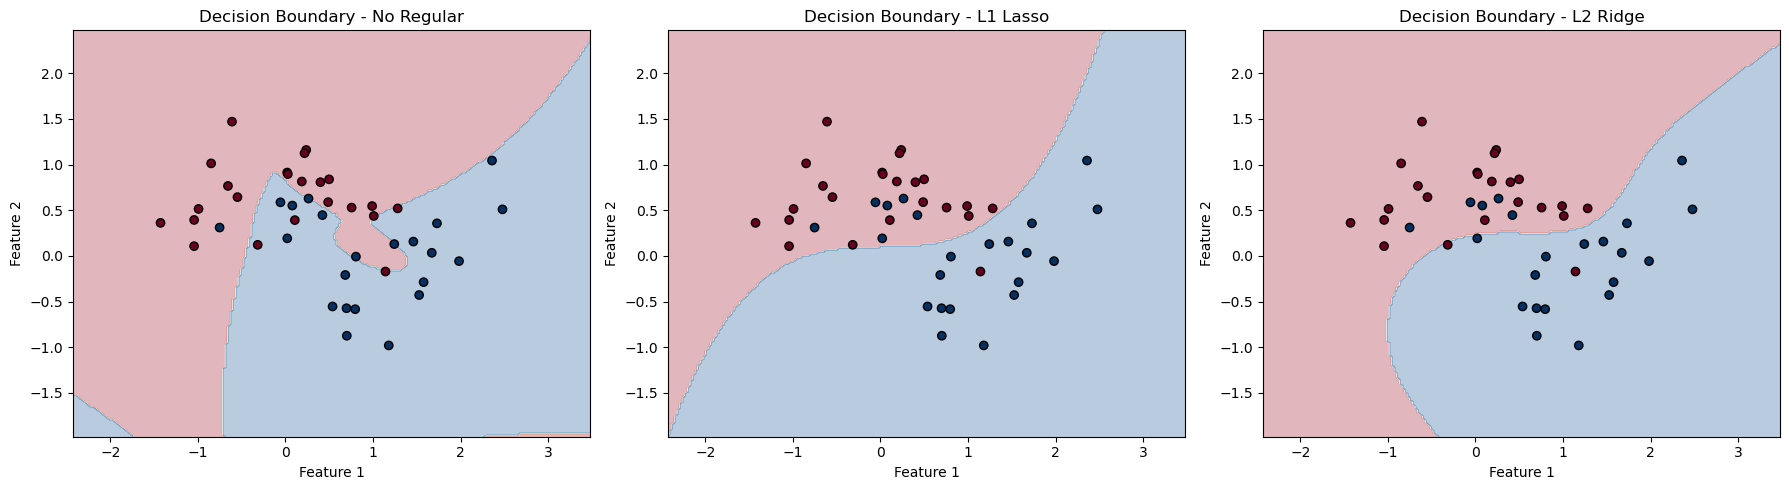

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Create grid
x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
y_min, y_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Flatten grid
grid = np.c_[xx.ravel(), yy.ravel()]

# Prepare figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, clf) in zip(axes, models):
    # Fit each model on the same transformed train data
    clf.fit(X_train_poly, y_train)

    # Apply the same transformations to the grid
    grid_poly = scaler.transform(poly.transform(grid))

    # Predict on grid and reshape for contour plot
    Z = clf.predict(grid_poly)
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')

    # Overlay test data
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu', edgecolors='k')

    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_title(f"Decision Boundary - {name}")

plt.tight_layout()
plt.show()

Le modèle sans régularisation surapprend (frontière très complexe). La pénalité L1 simplifie la frontière en annulant certains coefficients, tandis que la L2 l'adoucit sans annuler les variables.

## Partie 2 : Application sur des Données de Grande Dimension

### 2.1. Chargement du Nouveau Jeu de Données

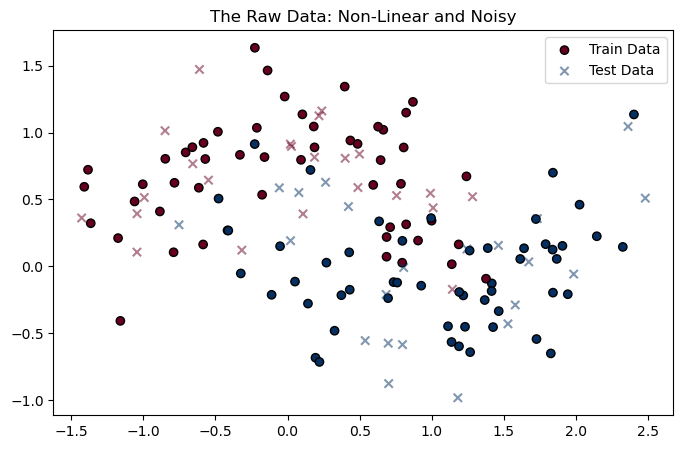

In [52]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=3000,
    n_features=50,
    n_informative=10,   
    n_redundant=10,     
    n_repeated=0,
    n_classes=2,
    random_state=42
)

# Plot the raw data
plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdBu', edgecolors='k', label='Train Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu', marker='x', alpha=0.5, label='Test Data')
plt.title("The Raw Data: Non-Linear and Noisy")
plt.legend()
plt.show()

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

### 2.2. Application des Transformations Polynomiales (Le Fléau de la Dimension)

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

models = [
    ("No Regular", LogisticRegression(penalty=None)),
    ("L1 Lasso", LogisticRegression(penalty='l1', solver='liblinear', C=0.5)),
    ("L2 Ridge", LogisticRegression(penalty='l2', C=0.5))
]

degrees = [2, 3]

results = {}

for d in degrees:
    print(f"\n===== Degree {d} =====")
    
    poly = PolynomialFeatures(degree=d, include_bias=False)
    scaler = StandardScaler()

    X_train_poly = scaler.fit_transform(poly.fit_transform(X_train))
    X_test_poly = scaler.transform(poly.transform(X_test))

    results[d] = {"train": [], "test": []}

    for name, model in models:
        model.fit(X_train_poly, y_train)

        y_train_pred = model.predict(X_train_poly)
        y_test_pred = model.predict(X_test_poly)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        results[d]["train"].append(train_acc)
        results[d]["test"].append(test_acc)

        print(f"{name} → Train: {train_acc:.2f}, Test: {test_acc:.2f}")


===== Degree 2 =====
No Regular → Train: 1.00, Test: 0.89
L1 Lasso → Train: 1.00, Test: 0.93
L2 Ridge → Train: 1.00, Test: 0.89

===== Degree 3 =====
No Regular → Train: 1.00, Test: 0.87
L1 Lasso → Train: 1.00, Test: 0.93
L2 Ridge → Train: 1.00, Test: 0.89


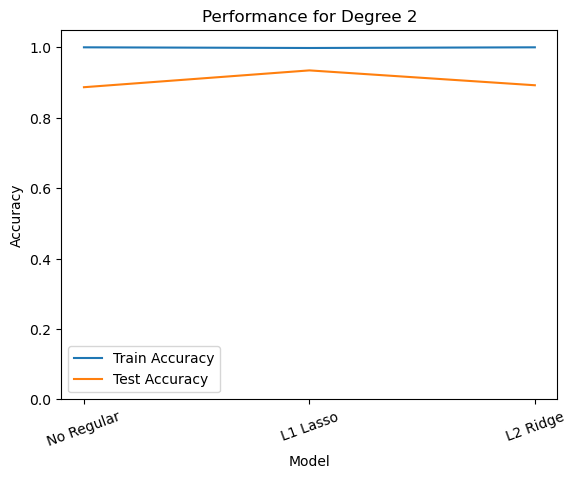

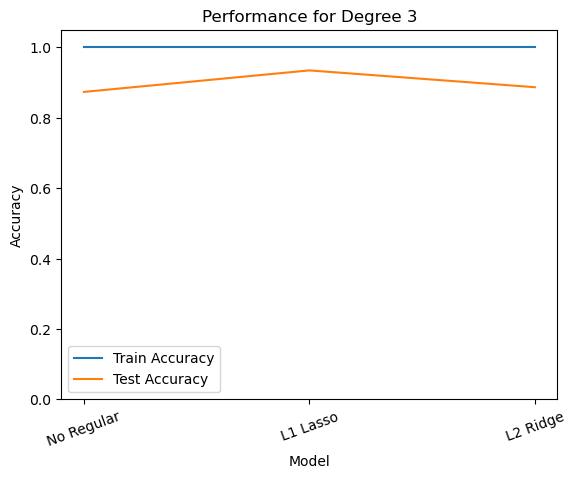

In [55]:
for d in degrees:
    plt.figure()
    
    plt.plot([m[0] for m in models], results[d]["train"], label="Train Accuracy")
    plt.plot([m[0] for m in models], results[d]["test"], label="Test Accuracy")
    
    plt.title(f"Performance for Degree {d}")
    plt.xlabel("Model")
    plt.ylabel("Accuracy")
    plt.legend()
    
    plt.xticks(rotation=20)
    plt.ylim(0, 1.05)
    plt.show()

In [56]:
X_2d = X[:, :2]

X_train, X_test, y_train, y_test = train_test_split(
    X_2d, y, test_size=0.3, random_state=42
)


===== Degree 2 =====


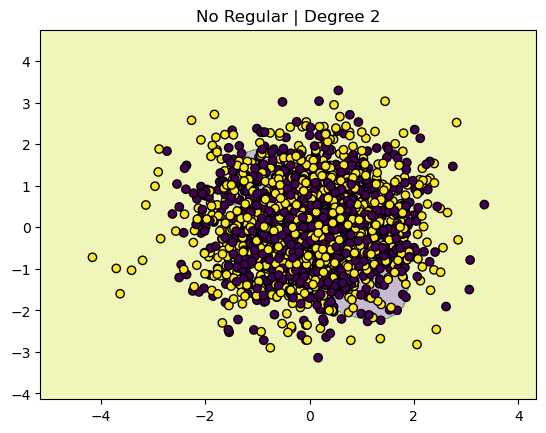

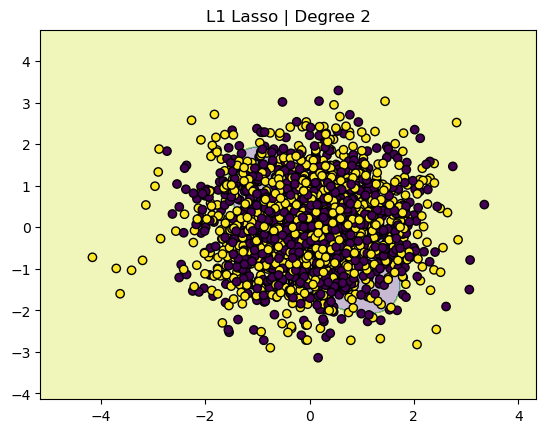

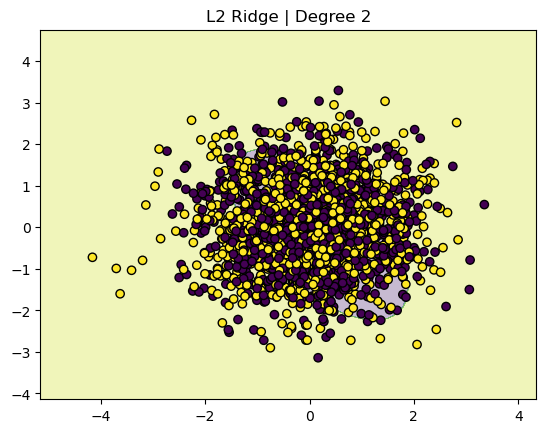


===== Degree 3 =====


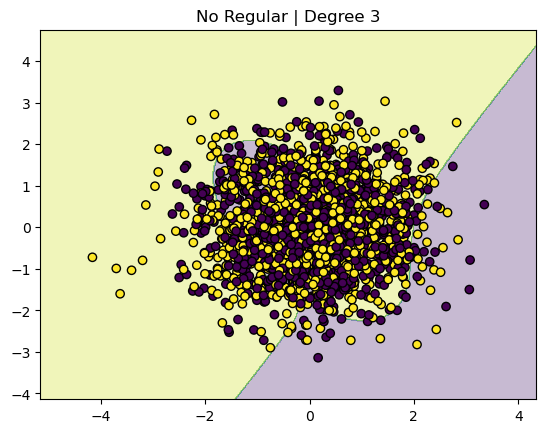

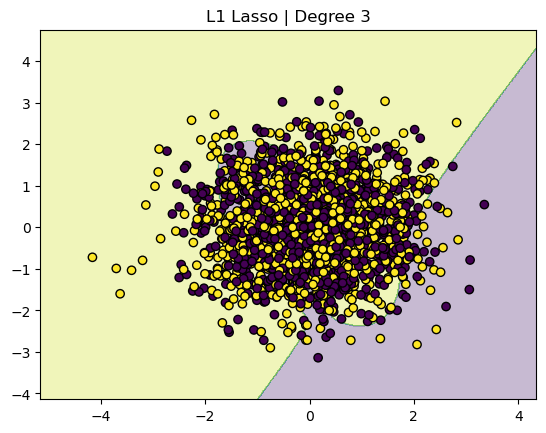

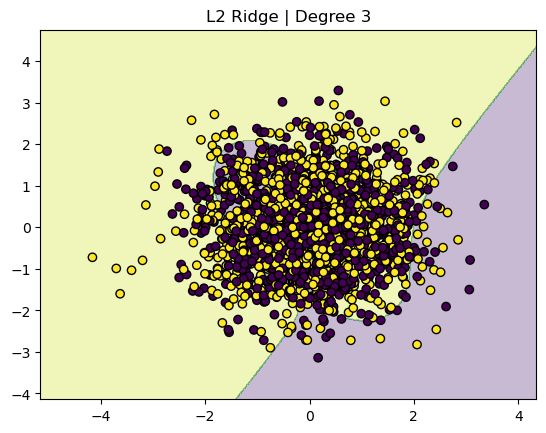

In [57]:
import numpy as np
import matplotlib.pyplot as plt

models = [
    ("No Regular", LogisticRegression(penalty=None)),
    ("L1 Lasso", LogisticRegression(penalty='l1', solver='liblinear', C=0.5)),
    ("L2 Ridge", LogisticRegression(penalty='l2', C=0.5))
]

degrees = [2,3]

h = 0.02

for d in degrees:
    print(f"\n===== Degree {d} =====")
    
    poly = PolynomialFeatures(degree=d, include_bias=False)
    scaler = StandardScaler()

    X_train_poly = scaler.fit_transform(poly.fit_transform(X_train))
    X_test_poly = scaler.transform(poly.transform(X_test))

    # Création de la grille
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    for name, model in models:
        model.fit(X_train_poly, y_train)

        Z = model.predict(
            scaler.transform(
                poly.transform(np.c_[xx.ravel(), yy.ravel()])
            )
        )
        Z = Z.reshape(xx.shape)

        plt.figure()
        plt.contourf(xx, yy, Z, alpha=0.3)

        plt.scatter(X_train[:, 0], X_train[:, 1],
                    c=y_train, edgecolors='k')

        plt.title(f"{name} | Degree {d}")
        plt.show()

## Proposition d'un Pipeline

Combiner la création des polynômes, la standardisation et l'entraînement dans un seul objet Pipeline de Scikit-Learn pour un code plus propre.

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression


pipeline_l1 = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),            # Étape 1 : Création des polynômes
    ('scaler', StandardScaler()),                      # Étape 2 : Standardisation
    ('logreg', LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=1000)) 
])

pipeline_l1.fit(X_train, y_train)

print("Pipeline entraîné avec succès !")
print(f"Pipeline Train accuracy: {pipeline_l1.score(X_train, y_train):.4f}")

Pipeline entraîné avec succès !
Pipeline Train accuracy: 0.5252
